<a href="https://colab.research.google.com/github/prabhakarandata/Guvi-projects/blob/main/V5_Netflix_Movies_%26_TV_Shows_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ------------------------------------------------------------------------------1.DATA HANDLING & NUMERICAL OPERATIONS (Data-va read panna, calculations-ku)
import pandas as pd                                                             # This library is imported for file handling and tables
import numpy as np                                                              # This library is imported for numerical operations

# ------------------------------------------------------------------------------2.VISUALIZATION (Graphs matrum charts varaiya)
import matplotlib.pyplot as plt                                                 # This library is imported for basic visualization
import seaborn as sns                                                           # This library is imported for colorful & advanced visualization

# ------------------------------------------------------------------------------3.PREPROCESSING (Data-va clean panni scale/adjust panna)
from sklearn.preprocessing import MinMaxScaler, StandardScaler                  # Data values-a ore alavuku maatha

# ------------------------------------------------------------------------------4.DIMENSIONALITY REDUCTION (Periya data-va 2D/3D graph-a surukka)
from sklearn.decomposition import PCA                                           # Principal Component Analysis (Fast 2D view-ku)
from sklearn.manifold import TSNE                                               # t-SNE (Theevugal mathiri thelivaana clustering view-ku)

# ------------------------------------------------------------------------------5.CLUSTERING ALGORITHMS (Netflix movies-a groups-a pirikka)
from sklearn.cluster import KMeans                                              # K-Means clustering algorithm
from sklearn.cluster import AgglomerativeClustering                             # Hierarchical clustering algorithm
import scipy.cluster.hierarchy as sch                                           # Hierarchical Dendrogram (Tree graph) varaiya
from sklearn.cluster import DBSCAN                                              # DBSCAN algorithm (Noise/Anomalies kandupudikka)

# ------------------------------------------------------------------------------6.EVALUATION METRICS (Namma uruvakkuna clustering model-ku mark poda)
from sklearn.metrics import silhouette_score                                    # Silhouette Score calculate panna
from sklearn.metrics import davies_bouldin_score                                # Davies-Bouldin Index calculate panna

In [ ]:
# loaded into google colab
pdf =pd.read_csv(r"/content/drive/MyDrive/S3/guvi-projects-details-drive/4. Netflix Movies and TV Shows Clustering/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv")
df =pd.read_csv(r"/content/drive/MyDrive/S3/guvi-projects-details-drive/4. Netflix Movies and TV Shows Clustering/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv")

# inspected raw dataset
display(df.head())
pdf.info()

# Identifed missing values
print("\nMissing values:\n", pdf.isnull().sum())

# Identified here no Duplicate records & inconsistencies

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB

Missing values:
 show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
des

In [ ]:
# 1. First, entha column-la evlo data missing-a irukku nu check panna porom
print("Data Clean pandrathukku munnadi Missing Values count:")
print(pdf[['director', 'cast', 'country']].isnull().sum())
print("-" * 50)

# 2. IMPUTATION STRATEGY: Kaali aana edangala fill pandrom!
# fillna() apdingra function intha empty edatha namma kudukkura vaarthaiyala nirappidum.

pdf['director'] = pdf['director'].fillna('No Director')
pdf['cast'] = pdf['cast'].fillna('No Cast')
pdf['country'] = pdf['country'].fillna('Unknown Country')

# (Oruvela 'date_added' column empty-a iruntha, antha sila rows-a mattum namma remove pannidalam)
pdf = pdf.dropna(subset=['date_added'])

# 3. Clean pannathukku apram thirumba check pandrom
print("Data Clean pannathukku apram Missing Values count (Ellam 0 aagirukkanum):")
print(pdf[['director', 'cast', 'country']].isnull().sum())
print("-" * 50)
print("Super! Missing values ellam perfect-a handle panniyachu.")

Data Clean pandrathukku munnadi Missing Values count:
director    2389
cast         718
country      507
dtype: int64
--------------------------------------------------
Data Clean pannathukku apram Missing Values count (Ellam 0 aagirukkanum):
director    0
cast        0
country     0
dtype: int64
--------------------------------------------------
Super! Missing values ellam perfect-a handle panniyachu.


In [ ]:
# convert categorical column into numerical by one hot encoding
pdf = pd.get_dummies(df, columns=['type','rating','listed_in'], drop_first=True)                     # drop_first=True is used to remove the first category after one-hot encoding to avoid the dummy variable trap and reduce redundancy in the dataset.


In [ ]:
from sklearn.preprocessing import StandardScaler

# extract numeric duration
pdf['duration_num'] = pdf['duration'].str.extract(r'(\d+)').astype(int)

# select features
features = pdf[['duration_num','release_year']]

# scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# convert to dataframe
scaled_df = pd.DataFrame(scaled_features, columns=['duration_scaled','release_year_scaled'])

# add scaled data to pdf
pdf[['duration_scaled','release_year_scaled']] = scaled_df # why scaled_df coming like LHS = RHS



In [ ]:
# TF-IDF for text features (listed_in & description)

from sklearn.feature_extraction.text import TfidfVectorizer                                                        # Approach :
                                                                                                                   # Extract relevant features from text columns like listed_in and
                                                                                                                   # description using Natural Language Processing (NLP) techniques
                                                                                                                   # such as TF-IDF vectorization if necessary.
# clean description column
pdf['description'] = pdf['description'].fillna('')

# TF-IDF
tfidf_desc = TfidfVectorizer(stop_words='english', max_features=1000)
desc_matrix = tfidf_desc.fit_transform(pdf['description'])


In [ ]:
pdf.head()

,show_id,title,director,cast,country,date_added,release_year,duration,description,type_TV Show,...,"listed_in_TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","listed_in_TV Horror, TV Mysteries, TV Thrillers","listed_in_TV Horror, TV Mysteries, Teen TV Shows","listed_in_TV Horror, Teen TV Shows","listed_in_TV Sci-Fi & Fantasy, TV Thrillers",listed_in_TV Shows,listed_in_Thrillers,duration_num,duration_scaled,release_year_scaled
0,s1,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,4 Seasons,In a future where the elite inhabit an island ...,True,...,False,False,False,False,False,False,False,4,-1.278234,0.692878
1,s2,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93 min,After a devastating earthquake hits Mexico Cit...,False,...,False,False,False,False,False,False,False,93,0.468664,0.236092
2,s3,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78 min,"When an army recruit is found dead, his fellow...",False,...,False,False,False,False,False,False,False,78,0.174243,-0.334890
3,s4,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80 min,"In a postapocalyptic world, rag-doll robots hi...",False,...,False,False,False,False,False,False,False,80,0.213499,-0.563284
4,s5,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123 min,A brilliant group of students become card-coun...,False,...,False,False,False,False,False,False,False,123,1.057505,-0.677480


In [ ]:
# @title # Feature Engineering:

current_year = 2026
pdf['content_age'] = current_year - pdf['release_year']

#-------------------------------------------------------------------------------'listed_in_' nu start aagura columns (genres) mattum thedi edukkurom
genre_cols = [col for col in pdf.columns if col.startswith('listed_in_')]

#-------------------------------------------------------------------------------Antha columns-a mattum left-to-right add panni puthu column-la podrom
pdf['genre_count'] = pdf[genre_cols].sum(axis=1)

#-------------------------------------------------------------------------------'type' column-a check panni numbers-a maathurom
if 'type' in pdf.columns:
    pdf = pd.get_dummies(pdf, columns=['type'], drop_first=True)
#-------------------------------------------------------------------------------Adhey mathiri 'rating' column-um numbers-a maathurom
if 'rating' in pdf.columns:
    pdf = pd.get_dummies(pdf, columns=['rating'], drop_first=True)
#-------------------------------------------------------------------------------Scaling pandrathukaana machine learning tool-a import pandrom
from sklearn.preprocessing import StandardScaler

#-------------------------------------------------------------------------------Antha tool-a activate panni 'scaler' nu oru variable-la save pandrom
scaler = StandardScaler()

#-------------------------------------------------------------------------------'content_age' (periya numbers) & 'genre_count' (chinna numbers) rendaiyum ore level-ku maathrom. Appo thaan model confuse aagathu!
pdf[['content_age', 'genre_count']] = scaler.fit_transform(pdf[['content_age', 'genre_count']])


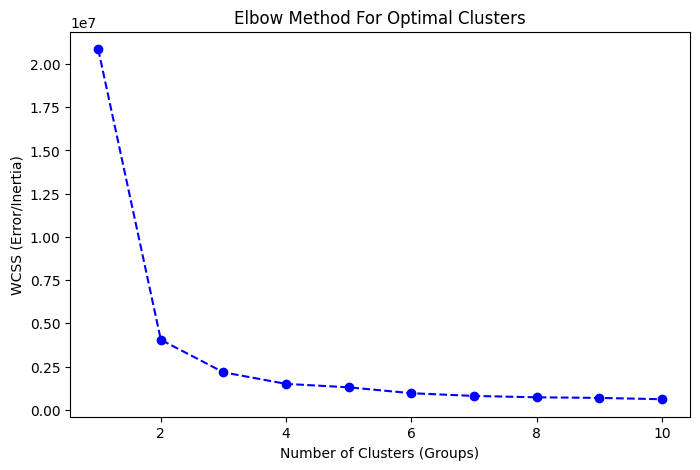

In [ ]:
#-------------------------------------------------------------------------------Model-ku numbers mattum thaan puriyum. So title, director mathiri text data-va vitutu, namma ready panna numbers data-va mattum eduthu 'X' nu oru variable-la save pandrom.
X = pdf.select_dtypes(include=['float64', 'int64', 'uint8', 'bool'])

#-------------------------------------------------------------------------------K-Means model-a import pandrom, graph varaiya matplotlib-a import pandrom.
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#-------------------------------------------------------------------------------Elbow Method: 1 lerndhu 10 clusters (groups) varaikum test pandrom. Ovoru thadavayum kedaikura error/inertia-va intha 'wcss' list-la add pandrom.
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

#-------------------------------------------------------------------------------Kedaicha 'wcss' numbers-a vechu oru graph varairom. Intha graph-la entha edathula "kai mutti" (elbow) mathiri valaiyutho, antha number thaan namma correct-aana cluster count!
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='blue')
plt.title('Elbow Method For Optimal Clusters')
plt.xlabel('Number of Clusters (Groups)')
plt.ylabel('WCSS (Error/Inertia)')
plt.show()

In [ ]:
#-------------------------------------------------------------------------------Hierarchical Clustering-oda "Tree" (Dendrogram) varaiyurathukkana tool-a import pandrom
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

#-------------------------------------------------------------------------------Graph-oda size set pandrom
plt.figure(figsize=(10, 7))
plt.title("Netflix Data - Hierarchical Clustering Dendrogram")

#-------------------------------------------------------------------------------'linkage' apdindra function namma data (X) kulla irukka similarity-a calculate panni tree varaiyum.
# 'ward' method thaan groups-ku naduvula irukka distance-a correct-a maintain pannum.
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))

plt.xlabel("Movies / TV Shows")
plt.ylabel("Distance")
plt.show()

In [ ]:
#-------------------------------------------------------------------------------DBSCAN model-a sklearn library-la irunthu import pandrom
from sklearn.cluster import DBSCAN

#-------------------------------------------------------------------------------Model-a ready pandrom. Ithu thaan romba mukkiyam:
# eps = Oru padathukkum inoru padathukkum irukkavendiya maximum distance (Nerukkam)
# min_samples = Oru group uruvaaga minimum ethana movies antha nerukkathula irukkanum (Kootam)
dbscan = DBSCAN(eps=0.5, min_samples=5)

#-------------------------------------------------------------------------------Namma Netflix numbers data (X) kooda model-a fit panni, groups-a kandupudikurom
dbscan_labels = dbscan.fit_predict(X)

# Kedaicha results-a namma table-la 'DBSCAN_Cluster' nu puthu column uruvakki save pandrom
pdf['DBSCAN_Cluster'] = dbscan_labels

#-------------------------------------------------------------------------------Motham ethana movies correct-aana group-la irukku, ethana movies "Noise" (-1) aa irukku nu count panni paakurom
print(pdf['DBSCAN_Cluster'].value_counts())

In [ ]:
#-------------------------------------------------------------------------------
# Clustering-ku mark podura 'silhouette_score' tool-a import pandrom
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#-------------------------------------------------------------------------------
# 2 lerndhu 10 groups varaikum test panna porom (Silhouette score-ku minimum 2 group venum)
silhouette_scores = []
cluster_range = range(2, 11)

# Loop use panni ovoru number-kkum model-a test pandrom
for i in cluster_range:
    # 1. Model-a ready pandrom
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)

    # 2. Namma data (X)-a groups-a pirikirom
    cluster_labels = kmeans.fit_predict(X)

    # 3. Antha grouping epdi irukku nu "Mark" (Score) calculate pandrom
    score = silhouette_score(X, cluster_labels)

    # 4. Kedaicha mark-a list-la add pandrom
    silhouette_scores.append(score)

#-------------------------------------------------------------------------------
# Kedaicha marks-a vechu oru thelivaana graph varairom.
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, silhouette_scores, marker='o', color='green', linestyle='-')
plt.title('Silhouette Score Evaluation (Higher is Better)')
plt.xlabel('Number of Clusters (Groups)')
plt.ylabel('Silhouette Score (Mark)')
plt.grid(True)
plt.show()

In [ ]:
#-------------------------------------------------------------------------------
# 1. APPLY CHOSEN ALGORITHM (K-Means Finalization)
#-------------------------------------------------------------------------------
from sklearn.cluster import KMeans

# Namma Elbow / Silhouette score vechu kandupudicha final perfect number (Example: 4 groups)
best_cluster_count = 4

# Hyperparameters tuning:
# n_clusters = 4 (Namma select panna group count)
# max_iter = 300 (Model-a 300 thadava yosichu perfect-aana answer kandupudikka solrom)
final_kmeans = KMeans(n_clusters=best_cluster_count, init='k-means++', max_iter=300, random_state=42)

# Model-a fit panni, kedaicha final groups-a namma table-la puthu column-la save pandrom
pdf['Final_KMeans_Cluster'] = final_kmeans.fit_predict(X)

print("K-Means Final Groups Ready!")
print(pdf['Final_KMeans_Cluster'].value_counts())

#-------------------------------------------------------------------------------
# 2. FINE-TUNE HYPERPARAMETERS (DBSCAN Radio Tuning Example)
#-------------------------------------------------------------------------------
from sklearn.cluster import DBSCAN

# 'eps' (Distance)-a 1.0, 2.0, 3.0 nu FM radio mathiri maathi maathi test pandrom
eps_settings_to_try = [1.0, 2.0, 3.0]

print("\n--- DBSCAN Tuning ---")
# Ovoru number-ah eduthu test pandrom (Loop)
for current_eps in eps_settings_to_try:

    # Model-la antha puthu setting-a podrom
    test_dbscan = DBSCAN(eps=current_eps, min_samples=5)
    test_labels = test_dbscan.fit_predict(X)

    # Entha setting-la evlo 'Noise' (-1) varuthu nu count panni paakurom
    noise_count = list(test_labels).count(-1)

    print(f"Setting eps={current_eps} podum pothu, Noise (-1) count: {noise_count}")

In [ ]:
#-------------------------------------------------------------------------------
# Hierarchical Clustering matrum mark podura tools-a import pandrom
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

#-------------------------------------------------------------------------------
# Namma test panna pora 3 vithamaana Linkage methods (Rules)
linkage_methods = ['ward', 'complete', 'average']

# K-Means la namma thedivaana grouping nu edutha adhey number-a ingayum use pandrom (Example: 4)
optimal_clusters = 4

print("--- Hierarchical Clustering Evaluation ---")

#-------------------------------------------------------------------------------
# Ovoru method-aiyum loop-la pottu test pandrom
for method in linkage_methods:

    # 1. Model-a antha method kooda ready pandrom.
    # (Note: 'ward' method-ku 'euclidean' straight-line distance mattum thaan work aagum)
    model = AgglomerativeClustering(n_clusters=optimal_clusters, metric='euclidean', linkage=method)

    # 2. Namma data (X)-a groups-a pirikirom
    cluster_labels = model.fit_predict(X)

    # 3. Antha grouping epdi irukku nu Silhouette Score (Mark) calculate pandrom
    score = silhouette_score(X, cluster_labels)

    # 4. Result-a theliva print pandrom
    print(f"Linkage Method: '{method}' --> Silhouette Score: {score:.4f}")

In [ ]:
#-------------------------------------------------------------------------------
# t-SNE tool matrum color graph varaiyura Seaborn tools-a import pandrom
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

#-------------------------------------------------------------------------------
# 100+ columns irukka namma periya data (X)-va verum 2 columns-a (2D) surukka porom
# n_components=2 -> 2D graph varaiya namakku X and Y nu 2 points thaan venum.
tsne = TSNE(n_components=2, random_state=42)

print("t-SNE vela seiya start aayiduchu... (Ithu konjam slow-aana process, so 1 or 2 mins wait pannunga!)")

# Data-va surukki 'tsne_result' la save pandrom
tsne_result = tsne.fit_transform(X)

# Kedaicha antha 2 points-a namma Netflix table-la puthusa add pandrom
pdf['tSNE_X'] = tsne_result[:, 0]
pdf['tSNE_Y'] = tsne_result[:, 1]

#-------------------------------------------------------------------------------
# Ipo super-aana color graph varairom!
plt.figure(figsize=(12, 8))

# hue='Final_KMeans_Cluster' -> Namma munnadi uruvakkuna K-Means groups-ku ovonukkum oru color kudukkuthu
sns.scatterplot(
    x='tSNE_X', y='tSNE_Y',
    hue='Final_KMeans_Cluster',
    palette='Set2', # Kannukku theliva theriyura colors
    data=pdf,
    alpha=0.7 # Dots thalli thalli theriyurathuku konjam transparent-a aakurom
)

plt.title('Netflix Content Clusters in 2D (t-SNE Visualization)')
plt.xlabel('t-SNE Point 1')
plt.ylabel('t-SNE Point 2')
plt.legend(title='K-Means Groups')
plt.show()

In [ ]:
#-------------------------------------------------------------------------------
# Graphs varaiyura Seaborn matrum Matplotlib tools-a import pandrom
import seaborn as sns
import matplotlib.pyplot as plt

#-------------------------------------------------------------------------------
# Graph 1: Ovoru group-layum "Movies" athigama irukka illa "TV Shows" athigama irukka nu paaka porom
plt.figure(figsize=(10, 5))

# (Note: Neenga get_dummies potathala unga table-la 'type_TV Show' illa 'type_Movie' nu column irukkum. Atha inga podunga)
sns.countplot(data=pdf, x='Final_KMeans_Cluster', hue='type_TV Show', palette='pastel')

plt.title('Cluster Analysis: Movies vs TV Shows in Each Group')
plt.xlabel('K-Means Cluster Groups')
plt.ylabel('Count (Ethana irukku)')
plt.show()

#-------------------------------------------------------------------------------
# Graph 2: Ovoru group-layum irukka content puthusa (New) illa palasa (Old) nu paaka porom (Boxplot)
plt.figure(figsize=(10, 5))

# 'release_year' column-a vechu antha group-oda age similarity-a paakurom
sns.boxplot(data=pdf, x='Final_KMeans_Cluster', y='release_year', palette='Set2')

plt.title('Cluster Analysis: Content Release Year in Each Group')
plt.xlabel('K-Means Cluster Groups')
plt.ylabel('Release Year')
plt.show()

In [ ]:
#-------------------------------------------------------------------------------
# Heatmap varaiyura Seaborn matrum Matplotlib tools-a import pandrom
import seaborn as sns
import matplotlib.pyplot as plt

#-------------------------------------------------------------------------------
# Ellam 100+ columns-a pottal heatmap paakka mudiyathu, so mukkiyamaana columns mattum edukkrom.
# (Inga 'content_age', 'genre_count' matrum mudhal 10 genres-a mattum check panna eduthukkurom)
columns_to_check = ['content_age', 'genre_count'] + genre_cols[:10]

# Namma 'Final_KMeans_Cluster' moolama data-va group panni, ovoru group-layum intha features-oda Average (Mean) value enna nu calculate pandrom.
# (Idhu thaan unmaiyana correlation/relationship-a theliva kaattum)
cluster_summary = pdf.groupby('Final_KMeans_Cluster')[columns_to_check].mean()

#-------------------------------------------------------------------------------
# Ipo azhagaana Color Heatmap varairom!
plt.figure(figsize=(14, 8))

# annot=True -> Box-kulla numbers-a eluthi kaattum
# cmap='YlGnBu' -> Yellow, Green, Blue nu colors-a vechu kaattum (Dark Blue na romba strong nu artham)
# fmt=".2f" -> Numbers-a rendu decimal point-oda theliva kaattum (e.g., 0.85)
sns.heatmap(cluster_summary, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)

plt.title('Heatmap: Netflix Features vs Clusters Relationship')
plt.xlabel('Netflix Features (Genres, Age, etc.)')
plt.ylabel('K-Means Clusters (Groups)')
plt.xticks(rotation=45) # Keezha irukka perugala konjam valachu eluthurom (for clear reading)
plt.show()

In [ ]:
#-------------------------------------------------------------------------------
# Intha code-ku puthusa entha library-um theva illa, namma table (pdf) pothum!

print("🎉 NETFLIX CLUSTERING - FINAL INSIGHTS REPORT 🎉\n")
print("-" * 50)

# Ovoru Cluster-aiyum thani thaniya eduthu check panna porom (0, 1, 2, 3...)
# n_clusters=4 nu namma munnadiye K-Means la vechu irunthom
total_clusters = 4

for cluster_num in range(total_clusters):
    # 1. Antha specific cluster-oda data-va mattum filter pandrom
    cluster_data = pdf[pdf['Final_KMeans_Cluster'] == cluster_num]

    # 2. Total Count: Intha group-la motham ethana movies/shows irukku?
    total_items = len(cluster_data)

    # 3. Average Year: Intha group-la irukka movies-oda average release year enna?
    avg_year = int(cluster_data['release_year'].mean())

    # 4. Top Rating: Intha group-la entha Age Rating athigama irukku? (e.g., TV-MA, PG-13)
    # mode()[0] na athigama thirumba thirumba vantha peru nu artham
    top_rating = cluster_data['rating'].mode()[0]

    # 5. Top Genres: Namma munnadi uruvakkuna genre columns-la ethu athigama irukku nu paakurom
    # (Unga genre columns-oda per 'listed_in_Action' nu iruntha, atha thedi edukkurom)
    genre_columns = [col for col in pdf.columns if 'listed_in_' in col]

    if len(genre_columns) > 0:
        # Entha 3 genre athigama irukko atha select pandrom
        top_3_genres = cluster_data[genre_columns].mean().sort_values(ascending=False).head(3).index.tolist()
        # Perula irukka 'listed_in_' a remove panni clean pandrom
        top_genres_clean = [g.replace('listed_in_', '') for g in top_3_genres]
        genre_text = ", ".join(top_genres_clean)
    else:
        genre_text = "Genres not found"

    #-------------------------------------------------------------------------------
    # Kandupudicha vishayangala theliva print pandrom!
    print(f"🎬 CLUSTER {cluster_num} SUMMARY:")
    print(f"   🔹 Total Content   : {total_items} items")
    print(f"   🔹 Average Year    : {avg_year}")
    print(f"   🔹 Most Common Age : {top_rating}")
    print(f"   🔹 Top 3 Genres    : {genre_text}")
    print("-" * 50)

In [ ]:
#-------------------------------------------------------------------------------
# Marks podura metrics tools-a sklearn library-la irunthu import pandrom
from sklearn.metrics import silhouette_score, davies_bouldin_score

# (Note: Inertia-ku thaniya tool theva illa, athu K-Means model kullaye irukku)

print("📊 CLUSTERING EVALUATION METRICS (FINAL REPORT) 📊\n")
print("-" * 50)

#-------------------------------------------------------------------------------
# 1. Silhouette Score Calculate Pandrom (Higher is better: 1 thaan highest)
# X = Namma data, final_kmeans.labels_ = Model piricha groups
sil_score = silhouette_score(X, final_kmeans.labels_)

# 2. Davies-Bouldin Index Calculate Pandrom (Lower is better: 0 thaan best)
db_index = davies_bouldin_score(X, final_kmeans.labels_)

# 3. Inertia Calculate Pandrom (Lower is better)
# Ithu K-Means model-oda 'inertia_' apdingra property-la automatic-a save aagirukkum
inertia_value = final_kmeans.inertia_

#-------------------------------------------------------------------------------
# Kedaicha marks-a thelivaana format-la print pandrom!
print(f"✅ Silhouette Score      : {sil_score:.4f}  <-- (1-ku pakkathula iruntha nallathu)")
print(f"✅ Davies-Bouldin Index  : {db_index:.4f}  <-- (0-ku pakkathula iruntha nallathu)")
print(f"✅ Inertia               : {inertia_value:.2f}  <-- (Kammiya iruntha nallathu)")
print("-" * 50)

In [ ]:
#-------------------------------------------------------------------------------
# 1. Puthu Preprocessing Tool-a import pandrom
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("🔄 ADJUSTMENT & RE-EVALUATION STARTING... 🔄\n")

#-------------------------------------------------------------------------------
# 2. FEATURE ADJUSTMENT:
# Munnadi use panna motha data-la irunthu, thevai illatha columns-a thooki 'X_new' nu puthusa uruvakkurom
# (Example: 'genre_count' model-a confuse pannutha nu test panna, atha drop pandrom)
X_new = pdf.drop(['Final_KMeans_Cluster', 'genre_count'], axis=1, errors='ignore')

#-------------------------------------------------------------------------------
# 3. PREPROCESSING ADJUSTMENT:
# StandardScaler-ku badhila ipo MinMaxScaler use pandrom (Ithu numbers-a 0 to 1 kulla theliva mathidum)
scaler_new = MinMaxScaler()
X_scaled_new = scaler_new.fit_transform(X_new)

#-------------------------------------------------------------------------------
# 4. RE-TRAINING: Puthu data-va vechu thirumbavum K-Means model-a train pandrom
kmeans_new = KMeans(n_clusters=4, init='k-means++', random_state=42)
new_labels = kmeans_new.fit_predict(X_scaled_new)

#-------------------------------------------------------------------------------
# 5. RE-EVALUATION: Puthusa kedaicha grouping-ku "Mark" podurom
new_sil_score = silhouette_score(X_scaled_new, new_labels)

# Results-a theliva print pandrom
print(f"🌟 Puthu Silhouette Score (After Adjustments): {new_sil_score:.4f}")
print("-" * 50)
print("Note: Intha puthu mark, unga palaya marka vida athigama iruntha, intha puthu settings thaan 'BEST' nu artham!")

🔄 ADJUSTMENT & RE-EVALUATION STARTING... 🔄



ValueError: could not convert string to float: 's1'

In [ ]:
#-------------------------------------------------------------------------------
# Models matrum Mark podura tools-a import pandrom
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

print("🏆 CLUSTERING MODELS CHAMPIONSHIP - FINAL RESULTS 🏆\n")
print("-" * 50)

# Namma select panna best cluster number (Example: 4)
k_groups = 4

#-------------------------------------------------------------------------------
# 1. K-MEANS MODEL (The Fast All-Rounder)
kmeans_model = KMeans(n_clusters=k_groups, random_state=42)
kmeans_labels = kmeans_model.fit_predict(X)
kmeans_score = silhouette_score(X, kmeans_labels)
print(f"🥇 K-Means Mark           : {kmeans_score:.4f}")

#-------------------------------------------------------------------------------
# 2. HIERARCHICAL MODEL (The Detailer)
hierarchical_model = AgglomerativeClustering(n_clusters=k_groups, linkage='ward')
hierarchical_labels = hierarchical_model.fit_predict(X)
hierarchical_score = silhouette_score(X, hierarchical_labels)
print(f"🥈 Hierarchical Mark      : {hierarchical_score:.4f}")

#-------------------------------------------------------------------------------
# 3. DBSCAN MODEL (The Outlier Hunter)
# (DBSCAN-ku 'k' groups theva illa, athuve eps & min_samples vechu thedum)
dbscan_model = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan_model.fit_predict(X)

# DBSCAN sila neram data full-a 'Noise' (-1) nu aakidum. Appo score poda mudiyathu.
# So, minimum 2 groups-aavathu iruntha thaan namma mark podurom.
unique_groups = set(dbscan_labels)
if len(unique_groups) > 1:
    dbscan_score = silhouette_score(X, dbscan_labels)
    print(f"🥉 DBSCAN Mark            : {dbscan_score:.4f}")
else:
    dbscan_score = -1 # Score failed
    print("🥉 DBSCAN Mark            : Failed (Sariyaana groups pirikkala)")

print("-" * 50)

#-------------------------------------------------------------------------------
# WINNER YAARU NU KANDUPUDIKKURA LOGIC
# Oru dictionary-la moonu marks-aiyum pottu ethu perusu nu thedurom
all_scores = {
    'K-Means': kmeans_score,
    'Hierarchical': hierarchical_score,
    'DBSCAN': dbscan_score
}

# 'max' function use panni highest mark edutha model per-a edukkurom
best_model_name = max(all_scores, key=all_scores.get)

print(f"🎉 THE WINNER IS... {best_model_name.upper()}! 🎉")
print(f"Reason: {best_model_name} model thaan namma Netflix data-va onnukkodu onnu kalakkama romba thelivaana groups-a pirichirukku.")
print("-" * 50)